# MDTest walkthrough notebook

This notebook gives a minimal, reproducible walkthrough of the revised MDTest command-line interface. It is intended as a user-facing companion to the manuscript and README, not as a separate analysis method.

Run this notebook from the package root directory, i.e. the directory containing `MDTest.py`.

In [1]:
from pathlib import Path
import subprocess
import sys
import json
from IPython.display import Image, Markdown, display

ROOT = Path.cwd()
if not (ROOT / "MDTest.py").exists():
    raise FileNotFoundError("Run this notebook from the MDTest package root directory containing MDTest.py")

OUT = ROOT / "notebook_results"
OUT.mkdir(exist_ok=True)

def run_mdtest(args):
    cmd = [sys.executable, "MDTest.py"] + list(args)
    print("$", " ".join(cmd))
    result = subprocess.run(cmd, cwd=ROOT, text=True, capture_output=True)
    if result.stdout:
        print(result.stdout)
    if result.stderr:
        print(result.stderr)
    result.check_returncode()
    return result

def show_text(path):
    path = Path(path)
    display(Markdown(f"```text\n{path.read_text()}\n```"))

def show_image(path):
    path = Path(path)
    if path.exists():
        display(Image(filename=str(path)))
    else:
        print(f"Missing image: {path}")


## 1. Manual NarK volume example

This reproduces a simple manual run on the NarK volume time series after discarding the initial transient and using block size `m=30`. The command writes a text report, a JSON report, and two PNG diagnostic figures.

$ c:\Users\jerry\Documents\GitHub\MDTestSourceCode\.venv\Scripts\python.exe MDTest.py manual --file examples/data/NarK_TimeSeriesData.csv --delim comma --drop-nan --col 6 --ts 600000 --m 30 --n max --outdir c:\Users\jerry\Documents\GitHub\MDTestSourceCode\notebook_results\manual_nark --prefix nark_volume_manual
MDTest revised: stationarity and uncertainty diagnostics for scalar MD time series
Jerry F. Wang, Haobin Wang, and Hai Lin

MDTest four-test diagnostic report
file: examples/data/NarK_TimeSeriesData.csv
column: 6 (Volume)
ts: 600000.0  start_index: 600  m: 30  n: 39  alpha: 0.05

mean_trend_mk: statistic=-0.84678108, p=0.39711716, pass=True, note=two-sided Mann--Kendall
dispersion_trend_mk: statistic=-1.9113059, p=0.055965286, pass=True, note=two-sided Mann--Kendall
normality_shapiro: statistic=0.95923077, p=0.16808744, pass=True, note=Shapiro--Wilk normality test
positive_serial_von_neumann: statistic=-0.23267175, p=0.40800815, pass=True, note=von Neumann ratio r=0.96273; lower

```text
MDTest four-test diagnostic report
file: examples/data/NarK_TimeSeriesData.csv
column: 6 (Volume)
ts: 600000.0  start_index: 600  m: 30  n: 39  alpha: 0.05

mean_trend_mk: statistic=-0.84678108, p=0.39711716, pass=True, note=two-sided Mann--Kendall
dispersion_trend_mk: statistic=-1.9113059, p=0.055965286, pass=True, note=two-sided Mann--Kendall
normality_shapiro: statistic=0.95923077, p=0.16808744, pass=True, note=Shapiro--Wilk normality test
positive_serial_von_neumann: statistic=-0.23267175, p=0.40800815, pass=True, note=von Neumann ratio r=0.96273; lower-tail positive-correlation test

mean: 935658.6775
standard error from block means: 88.43308823
95% t confidence interval: [935479.6541, 935837.7009]
overall_pass: True
recommendation: all tests passed under the selected diagnostic assumptions

```

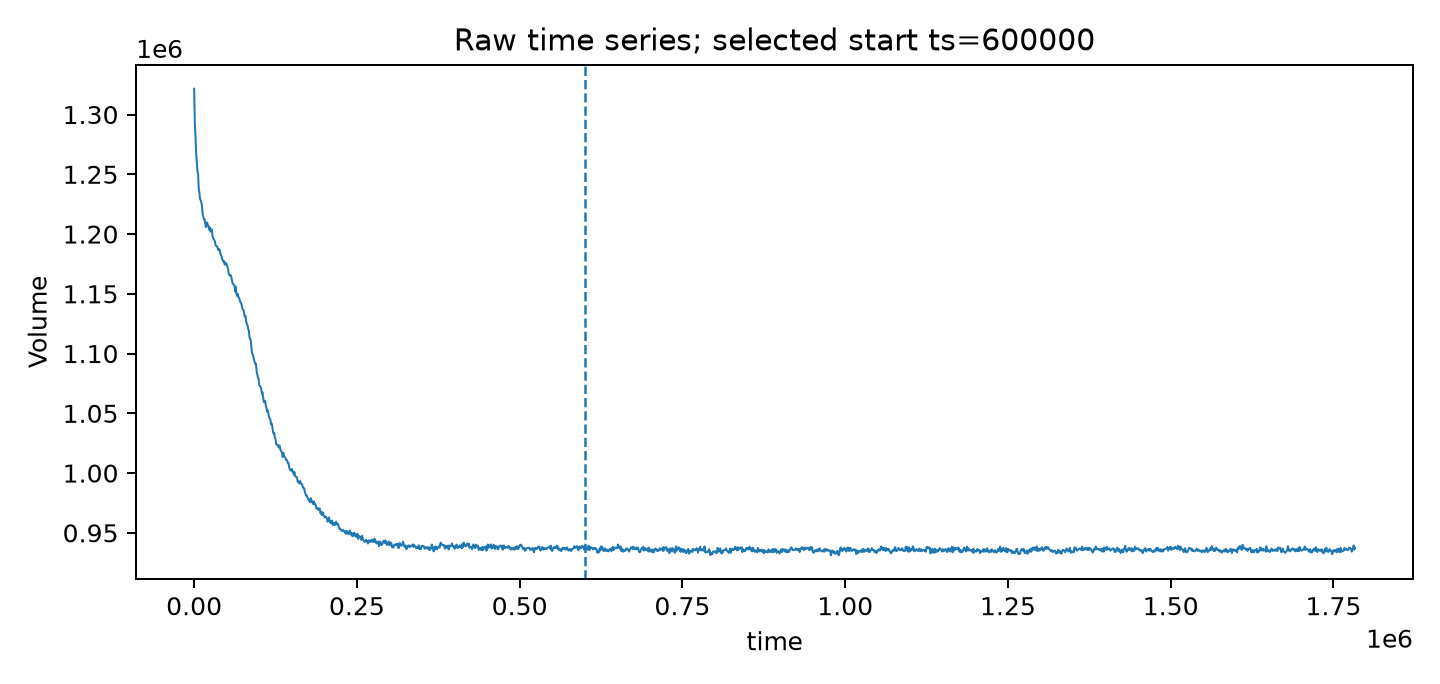

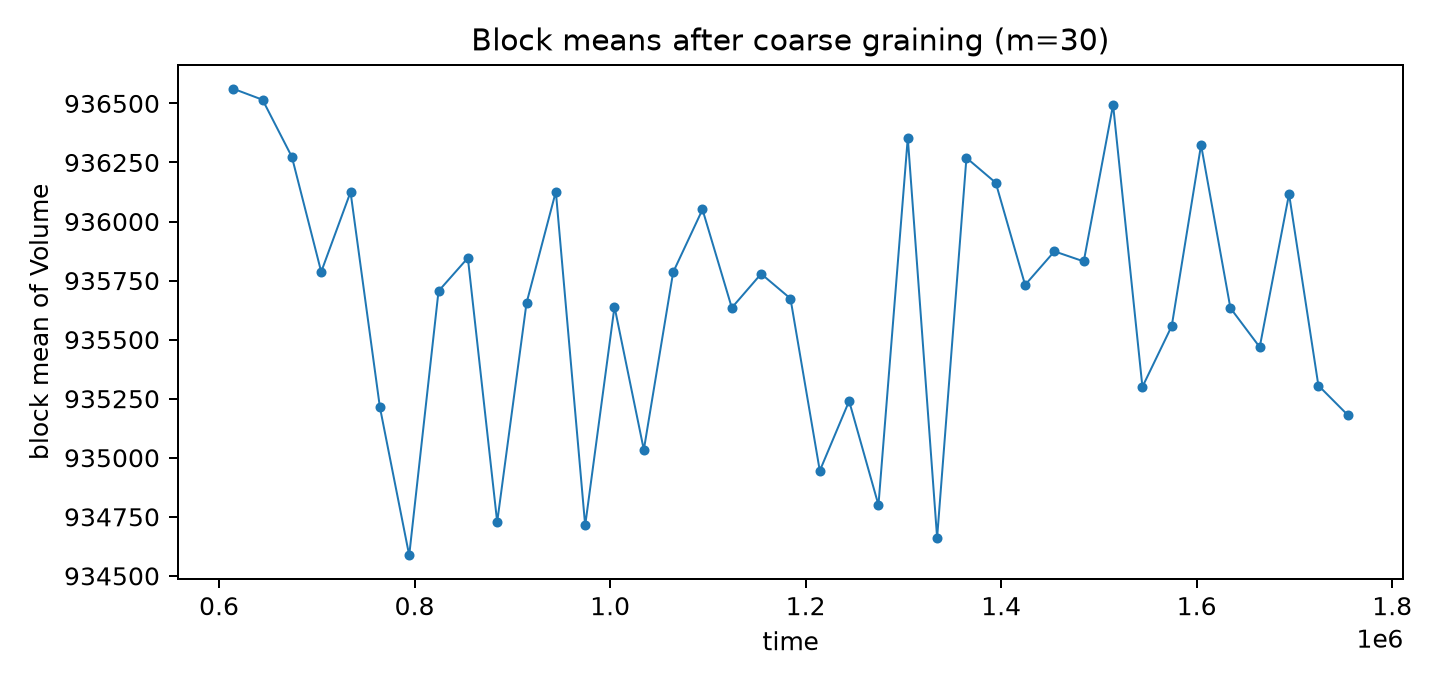

In [2]:
manual_dir = OUT / "manual_nark"
manual_dir.mkdir(exist_ok=True)
run_mdtest([
    "manual",
    "--file", "examples/data/NarK_TimeSeriesData.csv",
    "--delim", "comma",
    "--drop-nan",
    "--col", "6",
    "--ts", "600000",
    "--m", "30",
    "--n", "max",
    "--outdir", str(manual_dir),
    "--prefix", "nark_volume_manual",
])
show_text(manual_dir / "nark_volume_manual.txt")
show_image(manual_dir / "nark_volume_manual_raw.png")
show_image(manual_dir / "nark_volume_manual_blocks.png")


## 2. Automatic stationarity/correlation search on a synthetic stress test

The variance-relaxation data set is a controlled synthetic benchmark. The mean is zero by construction, but the fluctuation width relaxes. This example demonstrates the `auto-safe` workflow.

$ c:\Users\jerry\Documents\GitHub\MDTestSourceCode\.venv\Scripts\python.exe MDTest.py auto-safe --file examples/data/synthetic_variance_relaxation_independent.csv --delim comma --col 1 --m-trend-grid 2,5,10,20,40 --m-corr-grid 10,20,40,80,160,320 --outdir c:\Users\jerry\Documents\GitHub\MDTestSourceCode\notebook_results\auto_safe_variance_relaxation --prefix var_relax
MDTest revised: stationarity and uncertainty diagnostics for scalar MD time series
Jerry F. Wang, Haobin Wang, and Hai Lin

MDTest auto-safe summary
status: pass
file: examples/data/synthetic_variance_relaxation_independent.csv
column: 1 (variance_relaxation)
m_trend_grid: [2, 5, 10, 20, 40]; min_blocks=24; alpha=0.05
selected_ts_SW: 10374.0; selected_start_index_SW: 10374
selected_m_corr: 10; selected_n_corr: 962
note: found earliest candidate on scan grid passing all trend tests
Final four-test result:
MDTest four-test diagnostic report
file: examples/data/synthetic_variance_relaxation_independent.csv
column: 1 (varianc

```text
MDTest four-test diagnostic report
file: examples/data/synthetic_variance_relaxation_independent.csv
column: 1 (variance_relaxation)
ts: 10374.0  start_index: 10374  m: 10  n: 962  alpha: 0.05

mean_trend_mk: statistic=-1.1133688, p=0.26555006, pass=True, note=two-sided Mann--Kendall
dispersion_trend_mk: statistic=-1.0303836, p=0.30282999, pass=True, note=two-sided Mann--Kendall
normality_shapiro: statistic=0.99869383, p=0.7144733, pass=True, note=Shapiro--Wilk normality test
positive_serial_von_neumann: statistic=1.9438814, p=0.97404512, pass=True, note=von Neumann ratio r=1.06267; lower-tail positive-correlation test

mean: 0.01755821767
standard error from block means: 0.0105594177
95% t confidence interval: [-0.003163959407, 0.03828039475]
overall_pass: True
recommendation: all tests passed under the selected diagnostic assumptions

```

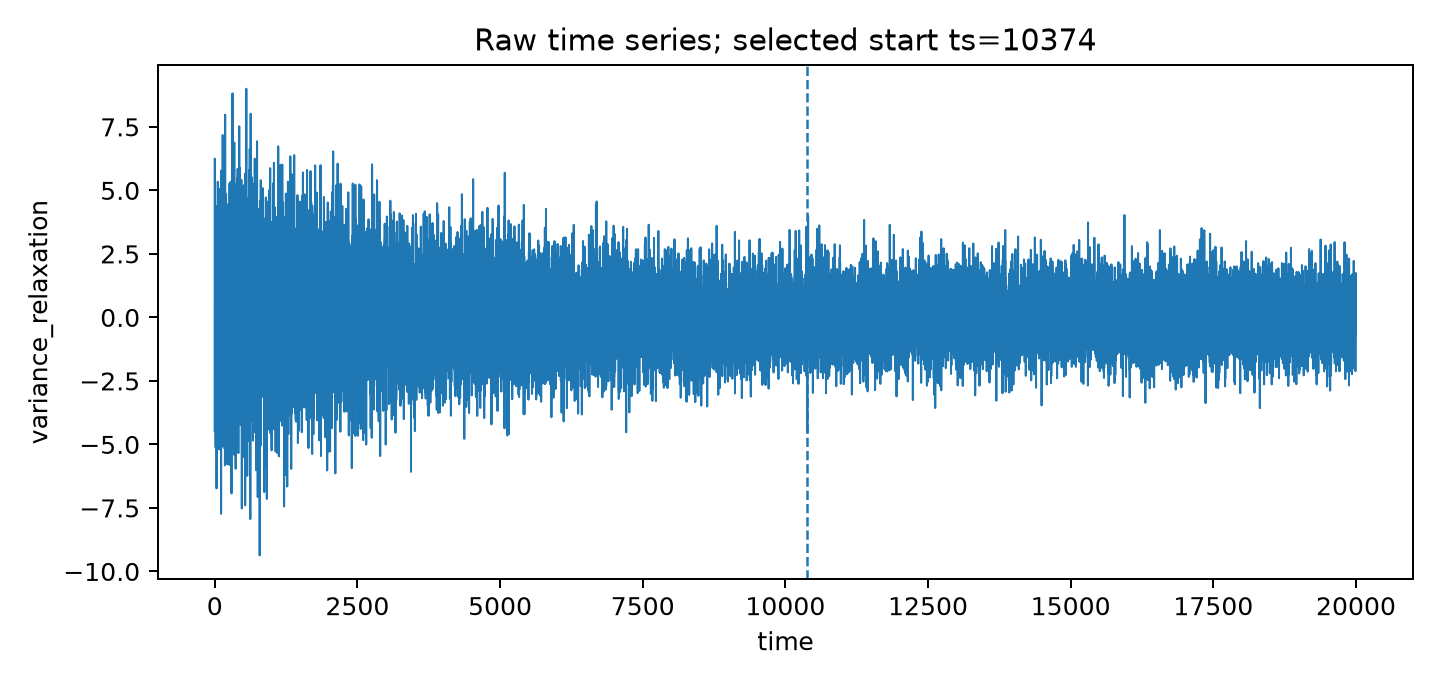

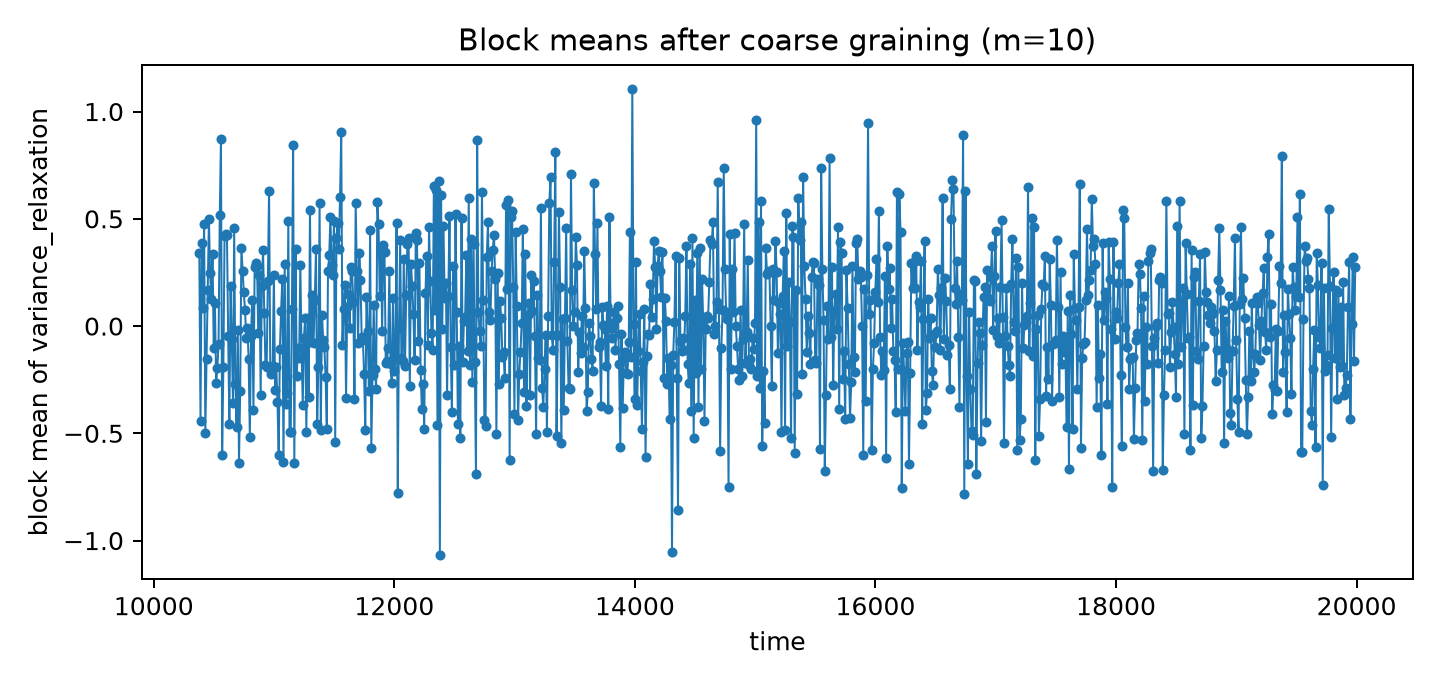

In [3]:
var_dir = OUT / "auto_safe_variance_relaxation"
var_dir.mkdir(exist_ok=True)
run_mdtest([
    "auto-safe",
    "--file", "examples/data/synthetic_variance_relaxation_independent.csv",
    "--delim", "comma",
    "--col", "1",
    "--m-trend-grid", "2,5,10,20,40",
    "--m-corr-grid", "10,20,40,80,160,320",
    "--outdir", str(var_dir),
    "--prefix", "var_relax",
])
summary = json.loads((var_dir / "var_relax_summary.json").read_text())
print(json.dumps({
    "status": summary["status"],
    "selected_ts_SW": summary["selected_ts_sw"],
    "selected_start_index_SW": summary["selected_start_index_sw"],
    "selected_m_corr": summary["selected_m_corr"],
    "selected_n_corr": summary["selected_n_corr"],
}, indent=2))
# The final manual result is written with a suffix indicating the selected m.
selected_m = summary["selected_m_corr"]
show_text(var_dir / f"var_relax_m{selected_m}.txt")
show_image(var_dir / f"var_relax_m{selected_m}_raw.png")
show_image(var_dir / f"var_relax_m{selected_m}_blocks.png")


## 3. ESS/IACT comparator

The `auto-compare` mode runs the MDTest stationarity screen and a Chodera/PyMBAR-style ESS/IACT start-time comparator, then reports a conservative start as the maximum of the two candidate starts.

$ c:\Users\jerry\Documents\GitHub\MDTestSourceCode\.venv\Scripts\python.exe MDTest.py auto-compare --file examples/data/synthetic_mean_drift_independent.csv --delim comma --col 1 --m-trend-grid 2,5,10,20,40 --m-corr-grid 10,20,40,80,160,320 --outdir c:\Users\jerry\Documents\GitHub\MDTestSourceCode\notebook_results\auto_compare_mean_drift --prefix mean_drift
MDTest revised: stationarity and uncertainty diagnostics for scalar MD time series
Jerry F. Wang, Haobin Wang, and Hai Lin

MDTest auto-safe summary
status: pass
file: examples/data/synthetic_mean_drift_independent.csv
column: 1 (mean_drift)
m_trend_grid: [2, 5, 10, 20, 40]; min_blocks=24; alpha=0.05
selected_ts_SW: 9709.0; selected_start_index_SW: 9709
selected_m_corr: 10; selected_n_corr: 1029
note: found earliest candidate on scan grid passing all trend tests
Final four-test result:
MDTest four-test diagnostic report
file: examples/data/synthetic_mean_drift_independent.csv
column: 1 (mean_drift)
ts: 9709.0  start_index: 9709  m: 

```text
MDTest four-test diagnostic report
file: examples/data/synthetic_mean_drift_independent.csv
column: 1 (mean_drift)
ts: 9709.0  start_index: 9709  m: 10  n: 1029  alpha: 0.05

mean_trend_mk: statistic=-1.7423853, p=0.081441047, pass=True, note=two-sided Mann--Kendall
dispersion_trend_mk: statistic=0.95352115, p=0.34032609, pass=True, note=two-sided Mann--Kendall
normality_shapiro: statistic=0.99915791, p=0.93375456, pass=True, note=Shapiro--Wilk normality test
positive_serial_von_neumann: statistic=0.28747111, p=0.61312419, pass=True, note=von Neumann ratio r=1.00896; lower-tail positive-correlation test

mean: -0.001293179522
standard error from block means: 0.009865814182
95% t confidence interval: [-0.02065261328, 0.01806625424]
overall_pass: True
recommendation: all tests passed under the selected diagnostic assumptions

```

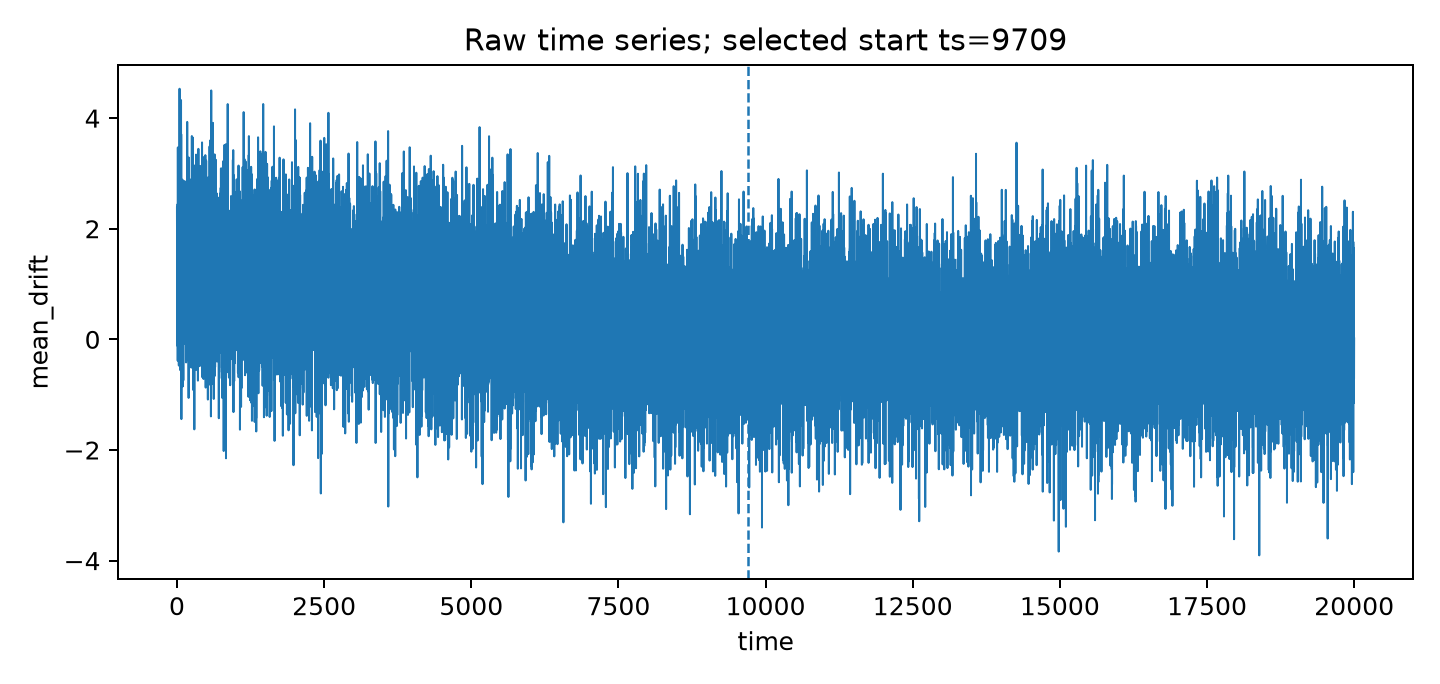

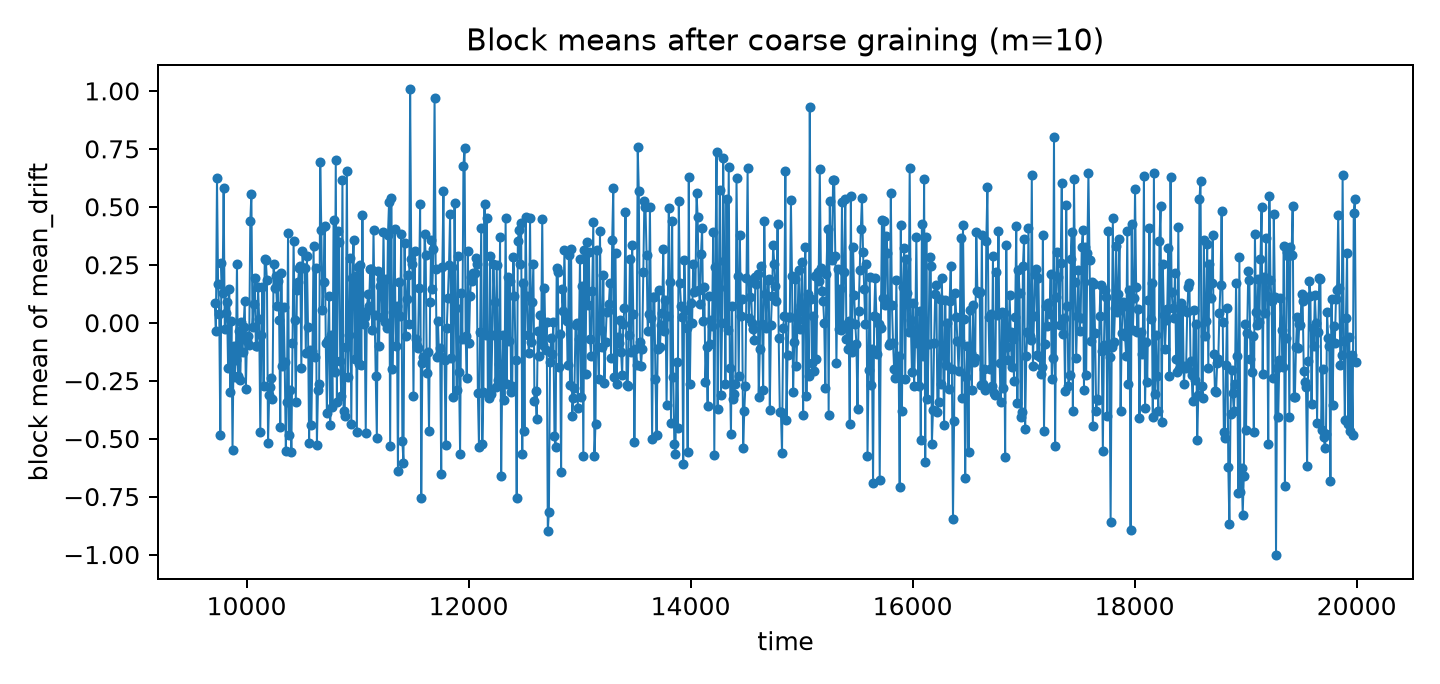

In [6]:
cmp_dir = OUT / "auto_compare_mean_drift"
cmp_dir.mkdir(exist_ok=True)
run_mdtest([
    "auto-compare",
    "--file", "examples/data/synthetic_mean_drift_independent.csv",
    "--delim", "comma",
    "--col", "1",
    "--m-trend-grid", "2,5,10,20,40",
    "--m-corr-grid", "10,20,40,80,160,320",
    "--outdir", str(cmp_dir),
    "--prefix", "mean_drift",
])
summary = json.loads((cmp_dir / "mean_drift_summary.json").read_text())
print(json.dumps({
    "status": summary["status"],
    "start_SW": summary["auto_safe"]["selected_ts_sw"],
    "start_ESS": summary["ess"]["selected_ts_ess"],
    "selected_ts_star": summary["selected_ts_star"],
    "selected_m_corr_star": summary["selected_m_corr_star"],
}, indent=2))
selected_m = summary["selected_m_corr_star"]
show_text(cmp_dir / f"mean_drift_star_m{selected_m}.txt")
show_image(cmp_dir / f"mean_drift_star_m{selected_m}_raw.png")
show_image(cmp_dir / f"mean_drift_star_m{selected_m}_blocks.png")


## 4. Interactive walkthrough mode

For a guided terminal session, run:

```bash
python MDTest.py
```

The walkthrough asks for the input file, delimiter, observable column, mode, and analysis parameters. It now saves the initial raw-data preview and displays it when the local Python/Jupyter environment supports interactive plotting. It also saves and displays the final raw/block diagnostic plots for manual and automated runs.